In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
import mne  

In [37]:
# Ruta de tu archivo
file_path = "..\data\A01E.gdf"

# Leer el archivo .gdf
# preload=True carga los datos en RAM, necesario para aplicar filtros o cambios
raw = mne.io.read_raw_gdf(file_path, preload=True)

# 1. Ver metadatos generales (frecuencia de muestreo, canales, etc.)
print(raw.info)

# 2. Listar los nombres de los canales
print(f"Canales detectados: {raw.ch_names}")

# 3. Ver la duración y n de muestras
print(f"Duración: {raw.times[-1]} segundos")

Extracting GDF parameters from ..\data\A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Pc\AppData\Local\Temp\ipykernel_15136\1358716135.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  file_path = "..\data\A01E.gdf"
C:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-19 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-19>
>
Canales detectados: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Duración: 2747.996 segundos


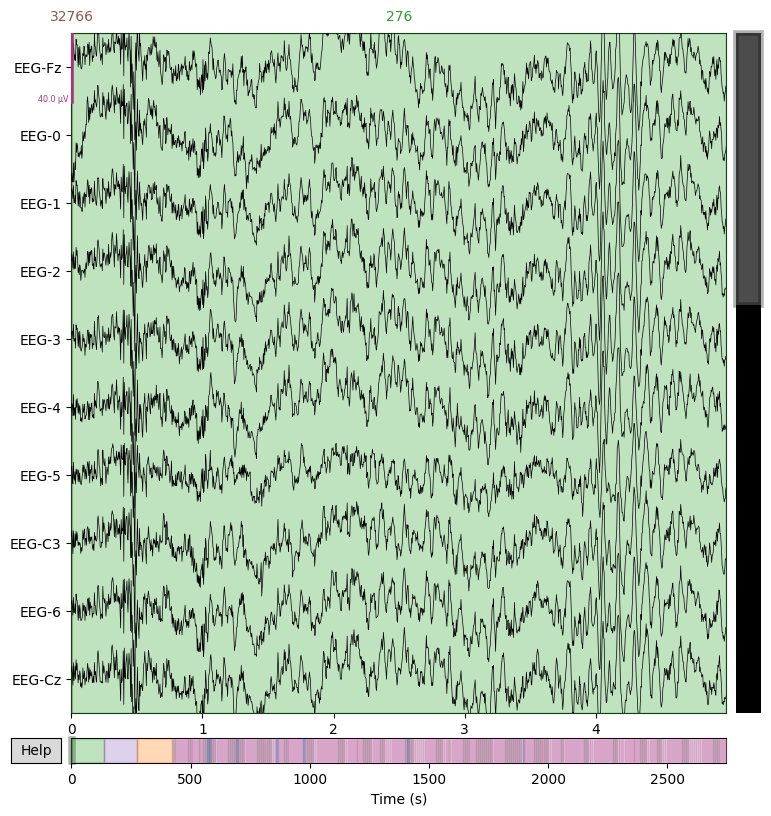

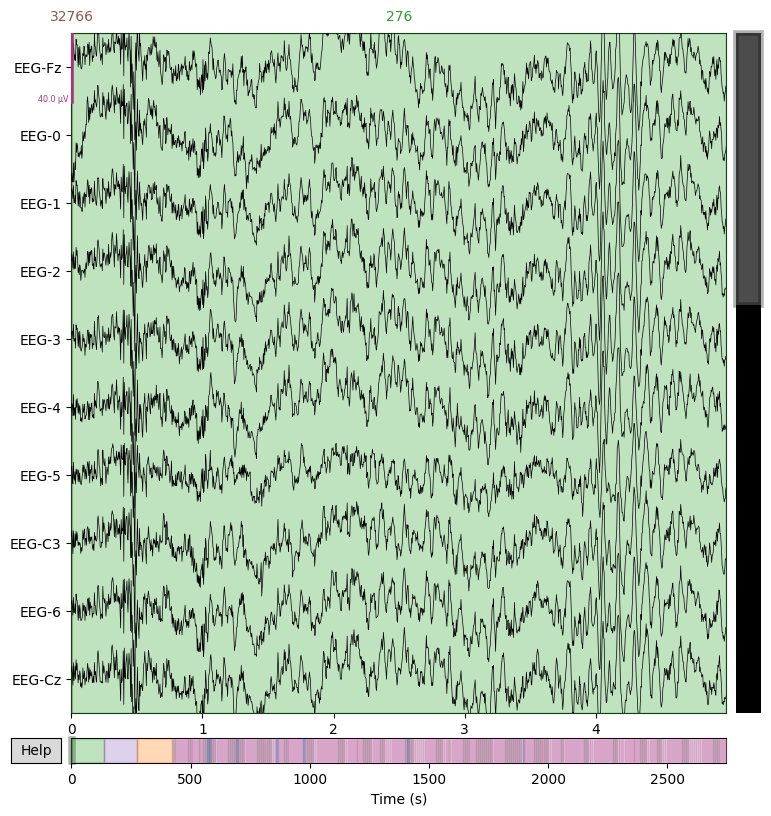

In [38]:
# Abre una ventana interactiva
# 'n_channels' define cuántos canales ver a la vez
# 'duration' define cuántos segundos de la línea de tiempo mostrar
raw.plot(n_channels=10, duration=5, title="Señales en el tiempo", show_scrollbars=True)

In [39]:
# Ver el resumen de la estructura
print(raw.info)

# Ver específicamente los tipos de canales
from collections import Counter
print(Counter(raw.get_channel_types()))

<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-19 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-19>
>
Counter({'eeg': 25})


In [40]:
# Convertir a DataFrame
df = raw.to_data_frame()

# Si prefieres que el tiempo sea el índice del DataFrame:
df_con_indice = raw.to_data_frame(index='time')

# Inspección rápida
print(df.head())
print(f"Columnas resultantes: {df.columns.tolist()}")

    time     EEG-Fz      EEG-0     EEG-1      EEG-2     EEG-3     EEG-4  \
0  0.000  11.230469 -27.246094  6.103516   4.882812  2.050781 -2.636719   
1  0.004   9.570312 -22.558594  7.910156   8.886719  4.150391  1.562500   
2  0.008  10.693359 -26.123047  5.615234   6.347656  4.296875  0.292969   
3  0.012   6.787109 -27.978516  1.904297   0.732422 -0.146484 -5.615234   
4  0.016  13.623047 -16.650391  9.570312  10.107422  8.447266  6.884766   

      EEG-5    EEG-C3     EEG-6  ...    EEG-11    EEG-12    EEG-13     EEG-14  \
0  3.027344  3.857422  4.785156  ...  6.396484  3.173828 -1.025391   5.712891   
1  4.980469  7.275391  6.835937  ...  7.617188  5.126953  1.123047   5.419922   
2 -2.050781  1.123047  2.929688  ...  1.367188  0.390625 -1.708984  -4.150391   
3 -5.371094 -6.250000 -2.148437  ... -5.908203 -4.443359 -5.664062 -10.595703   
4  7.373047  7.226562  8.398438  ...  7.666016  8.251953  7.666016   8.349609   

     EEG-Pz    EEG-15     EEG-16   EOG-left  EOG-central  EOG-

## Sección n°1

- Sección que muestra paso a paso como se desglosa las diferentes funciones para filtrar y seccionar las señales de BCI.

In [41]:
# Instalamos las librerias necesarias para poder procesar estas señales:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
from mne.io import read_raw_gdf
from mne import events_from_annotations
import glob
import logging

In [42]:
# agregamos las funciones que son para filtrar:

from scipy import signal


# La primera es Filtro Notch (Eliminación de Interferencia Eléctrica)
def get_notch_filter_coef(fs):
    # Notch filter at 50 Hz
    # Definimos el rango de parada (bandstop) entre 49 Hz y 51 Hz
    w0 = [49.0/(fs/2), 51.0/(fs/2)] 
    # Diseñamos un filtro Butterworth de orden 8
    return signal.butter(8, w0, btype='bandstop')


# Ejemplo de uso
fs = 250
b, a = get_notch_filter_coef(fs)

print(f"b (coeficientes del numerador): {b[:3]}...")
print(f"a (coeficientes del denominador): {a[:3]}...") 

b (coeficientes del numerador): [ 0.87911129 -4.34793836 16.44096937]...
a (coeficientes del denominador): [ 1.         -4.86619064 18.10265353]...


¿Qué ocurre? Estos coeficientes son como las "instrucciones" de una receta. El vector b dice cómo ponderar las muestras actuales de la señal, y a dice cómo ponderar las salidas anteriores.

In [43]:
# Filtro FIR (Finite Impulse Response)
def get_fir_filter_coef(order, freq_band=(48,52), fs=250, type= 'bandstop'):
    # Diseña los coeficientes de un filtro usando una ventana (window method)
    fir_coeff = signal.firwin(order + 1,[freq_band[0],freq_band[1]],pass_zero=type,fs=fs)
    return fir_coeff, 1.0

# Ejemplo
order = 100
b_fir, a_fir = get_fir_filter_coef(order, (48, 52), 250)

# La salida 'a' siempre es 1.0 en filtros FIR
print(len(b_fir)) # 101 coeficientes (pesos)

101


pass_zero: Si es 'bandstop', el filtro dejará pasar las frecuencias desde el cero hasta el primer corte, y luego desde el segundo corte en adelante.

Estabilidad: Los filtros FIR no tienen retroalimentación (no dependen de salidas anteriores), lo que los hace muy robustos, aunque requieren un orden más alto que los IIR para lograr la misma selectividad.

¿Qué ocurre? Imagina una "ventana" que se desliza sobre tu señal. Cada muestra dentro de la ventana se multiplica por un peso en b_fir y se suma. Al ser un filtro de orden 100, "mira" 100 muestras atrás para decidir el valor actual.

In [44]:
# Filtro Pasabanda Analógico y Transformada Bilineal

def get_bandpass_filter_coef(fs):
    from math import pi
    Fpa = 1     # Corte paso alto (High pass) en Hz
    Fpb = 40    # Corte paso bajo (Low pass) en Hz
    C1 = 100e-9 
    C2 = 1e-9
    R1 = 1 / (2 * pi * C1 * Fpa) 
    R2 = 1 / (2 * pi * C2 * Fpb)
    
    # Coeficientes del denominador (a) y numerador (b) de la función de transferencia H(s)
    a = [1, (1 / (C1*R2)) + (1 / (C1*R1)) + (1 / (C2*R2)), (1 / (C1*C2*R1*R2))] 
    b = [1 / (C2*R2), 0] 
    
    # Transformamos el diseño del dominio analógico (s) al digital (z)
    return signal.bilinear(b, a, fs)

# Ejemplo
b_analog, a_analog = get_bandpass_filter_coef(250)



Entrada: fs.

Salida: Coeficientes b y a resultantes de la Transformada Bilinial. 

$$H(s) = \frac{\frac{1}{C_2 R_2} s}{s^2 + (\frac{1}{C_1 R_2} + \frac{1}{C_1 R_1} + \frac{1}{C_2 R_2})s + \frac{1}{C_1 C_2 R_1 R_2}}$$

Definimos las resistencias ($R$) y capacitores ($C$) para que dejen pasar solo frecuencias entre 1 Hz y 40 Hz. La función signal.bilinear traduce ese mundo de "voltajes y componentes" al mundo de "ceros y unos" (digital).

In [45]:
# Filtro Pasabanda Estándar (Butterworth)

def get_bandpass_coef(N, low, high, fs):
    # N es el orden del filtro
    # Retorna los coeficientes b (numerador) y a (denominador)
    return signal.butter(N, [low, high], btype='bandpass', fs=fs)

In [46]:
# Funciones de Preprocesamiento

def preprocess_signal(senial, fs, filtfilt=False, band=[1, 40]):   
    b_notch, a_notch = get_notch_filter_coef(fs)
    # Aquí usa un Butterworth de orden 2 (N=1 resulta en orden 2 para pasabanda)
    b_bandpass, a_bandpass = get_bandpass_coef(N=1, low=band[0], high=band[1], fs=250)
    
    if filtfilt:
        # Filtrado de fase cero (hacia adelante y hacia atrás)
        senial = signal.filtfilt(b_notch, a_notch, senial)
        senial = signal.filtfilt(b_bandpass, a_bandpass, senial)
    else:
        # Filtrado causal convencional
        senial = signal.lfilter(b_notch, a_notch, senial) 
        senial = signal.lfilter(b_bandpass, a_bandpass, senial)
    return senial

lfilter vs filtfilt:

lfilter: Es un filtrado en tiempo real. Introduce un desplazamiento de fase (retraso temporal).

filtfilt: Aplica el filtro dos veces (una hacia adelante y otra hacia atrás). Esto elimina el retraso de fase, lo cual es excelente para análisis de datos ya grabados (offline), pero es imposible de usar en tiempo real porque requiere conocer el futuro de la señal.

In [47]:
def preprocess_signal_im_tention(senial, fs, filtfilt=True, filter_order=8, freq_band=[4, 40]):   
    b_notch, a_notch = get_notch_filter_coef(fs)
    
    # Se utiliza un orden mucho más alto (16 en total si N=8)
    b_bandpass, a_bandpass = get_bandpass_coef(N=filter_order, low=freq_band[0], high=freq_band[1], fs=fs)
    
    if filtfilt:
        senial = signal.filtfilt(b_notch, a_notch, senial)
        senial = signal.filtfilt(b_bandpass, a_bandpass, senial)
    else:
        senial = signal.lfilter(b_notch, a_notch, senial)
        senial = signal.lfilter(b_bandpass, a_bandpass, senial)
    return senial

En esta función, el rango de frecuencia comienza en 4 Hz en lugar de 1 Hz. Esto sugiere que se están ignorando las ondas Delta (asociadas al sueño profundo o artefactos de movimiento ocular) para enfocarse en ritmos más rápidos relacionados con la intención motora.

preguntas: 

¿que output sale de finalmente luego de pasar por estos filtros?

¿Por qué es tan importante quitar exactamente los 50 Hz? Si no usamos el filtro Notch, ¿qué le pasaría a mi gráfico de la señal cerebral?

¿Por qué en algunos casos el código filtra la señal hacia adelante y después hacia atrás (filtfilt)? ¿Qué problema arregla eso que no hace un filtro normal?

¿Por qué todas las funciones me piden la fs (frecuencia de muestreo)? ¿Qué pasaría si le erro a ese número al configurar el filtro?

In [48]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
from mne.io import read_raw_gdf
from mne import events_from_annotations
import glob
import logging

In [49]:
# hacer una funcion que reciba la frecuencia y grafique el espectro
# transformada de fourier
# graficas espetros de frecuencia
# siempre ver antes y despues de la señal

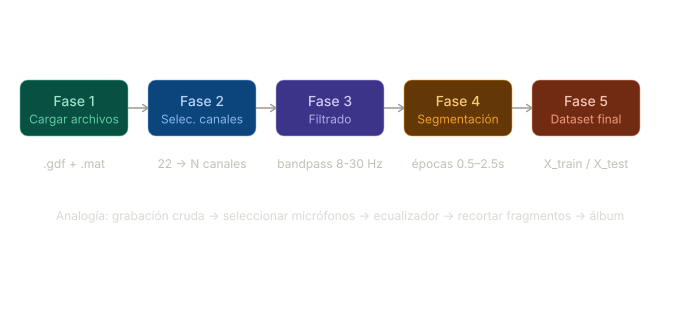

In [50]:
from IPython.display import SVG, display

# Visualización del archivo
display(SVG(filename='pipeline_eeg_fases.svg'))

In [51]:

import numpy as np
import scipy.io as sio
import scipy.signal as signal
import matplotlib.pyplot as plt
from pathlib import Path
from mne.io import read_raw_gdf
from mne import events_from_annotations
import glob, logging

# ── Paths ─────────────────────────────────────────────────────────────────────
# Analogía: DATA_DIR es el estante donde están todas las cintas
DATA_DIR = Path('../data')          # cambiá si tu estructura es distinta

# ── Parámetros de procesamiento ───────────────────────────────────────────────
CLASS_LABELS   = [1, 2]          # 1=mano izq, 2=mano der
BAND_PASS      = [8, 30]         # Hz
SEGMENT_LENGTH = 2               # segundos por época
OFFSET         = 0.5             # segundos post-cue antes de cortar
SEL_CHANNELS   = ['FC3', 'C5', 'C3', 'C1', 'CP3']

FS         = 250
STIM_CODES = [769, 770, 771, 772]
CHANNEL_LIST = [
    'Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz',
    'C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz','P2','POz'
]

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
print("✅ Config lista")
print(f"   Buscando archivos en: {DATA_DIR.resolve()}")

✅ Config lista
   Buscando archivos en: C:\Users\Pc\Desktop\CIRINS\Brain_Computer_Interface_Algorithms_Applied-\data


Archivos train EEG  encontrados: 9
Archivos test  EEG  encontrados: 9
Archivos train .mat encontrados: 0
Archivos test  .mat encontrados: 0
  ✅ train .gdf: OK
  ✅ test  .gdf: OK
  ⚠️  Se esperaban 9 archivos train .mat, encontrados: 0
  ⚠️  Se esperaban 9 archivos test  .mat, encontrados: 0


C:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



📋 Canales disponibles (25): ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
⏱  Duración train: 2690.1s  |  fs=250 Hz


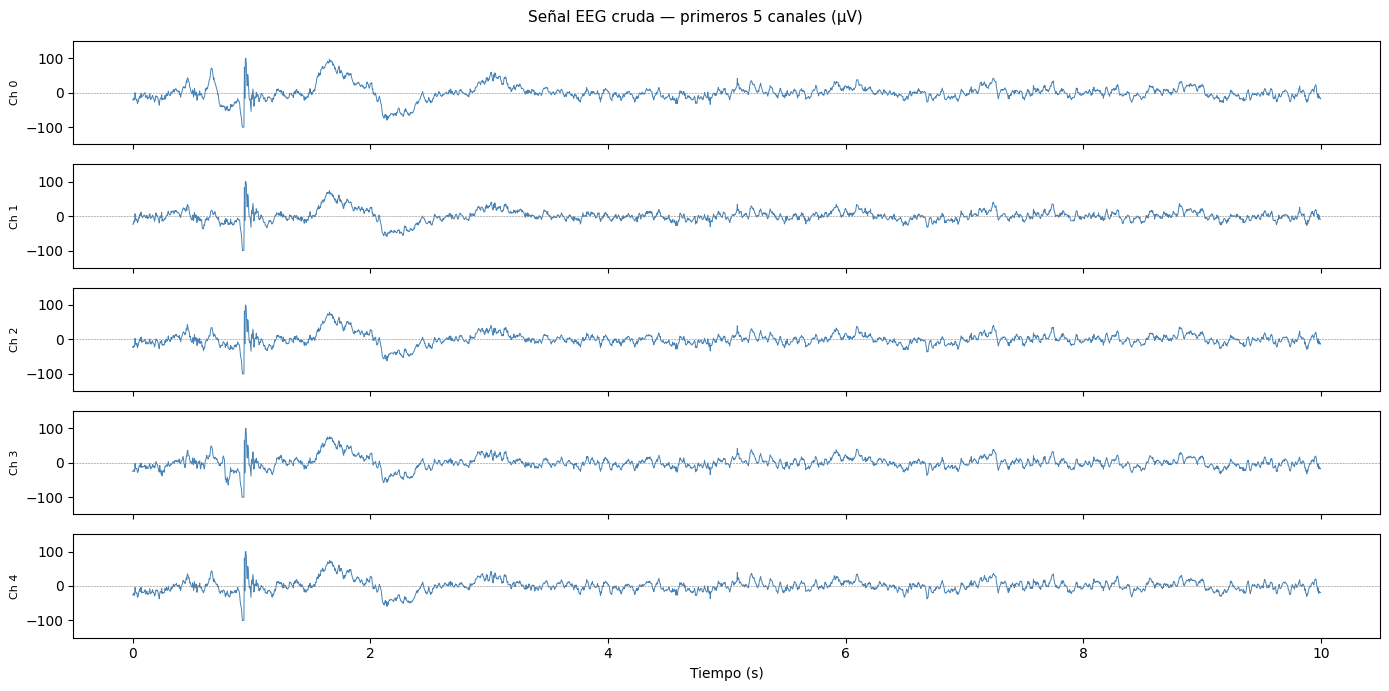

In [52]:
# ─── BLOQUE 1: Cargar archivos ────────────────────────────────────────────────

# Buscar los 18 archivos .gdf (9 train + 9 test)
# Patrón: A01T.gdf ... A09T.gdf  /  A01E.gdf ... A09E.gdf
train_eeg_files  = sorted(DATA_DIR.glob('*T.gdf'))
test_eeg_files   = sorted(DATA_DIR.glob('*E.gdf'))

# Convertir a strings para MNE (que no acepta Path objects en algunas versiones)
train_eeg_files   = [str(f) for f in train_eeg_files]
test_eeg_files    = [str(f) for f in test_eeg_files]
train_label_files = [str(f) for f in train_label_files]
test_label_files  = [str(f) for f in test_label_files]

# ── Verificación ──────────────────────────────────────────────────────────────
print(f"Archivos train EEG  encontrados: {len(train_eeg_files)}")
print(f"Archivos test  EEG  encontrados: {len(test_eeg_files)}")
print(f"Archivos train .mat encontrados: {len(train_label_files)}")
print(f"Archivos test  .mat encontrados: {len(test_label_files)}")

for lista, nombre in [(train_eeg_files,'train .gdf'),
                      (test_eeg_files, 'test  .gdf'),
                      (train_label_files,'train .mat'),
                      (test_label_files, 'test  .mat')]:
    if len(lista) != 9:
        print(f"  ⚠️  Se esperaban 9 archivos {nombre}, encontrados: {len(lista)}")
        for f in lista: print(f"      {f}")
    else:
        print(f"  ✅ {nombre}: OK")

# ── Cargar sujeto 1 para explorar ─────────────────────────────────────────────
SUBJ = 0
train_raw = read_raw_gdf(train_eeg_files[SUBJ], preload=True, verbose=False)
test_raw  = read_raw_gdf(test_eeg_files[SUBJ],  preload=True, verbose=False)

print(f"\n📋 Canales disponibles ({len(train_raw.ch_names)}): {train_raw.ch_names}")
print(f"⏱  Duración train: {train_raw.times[-1]:.1f}s  |  fs={int(train_raw.info['sfreq'])} Hz")

# ── Visualización: señal cruda primeros 10s ───────────────────────────────────
raw_data = train_raw.get_data()[:5, :FS*10]
fig, axes = plt.subplots(5, 1, figsize=(14, 7), sharex=True)
t = np.arange(raw_data.shape[1]) / FS
for i, ax in enumerate(axes):
    ax.plot(t, raw_data[i]*1e6, lw=0.7, color='steelblue')
    ax.set_ylabel(f'Ch {i}', fontsize=8)
    ax.set_ylim(-150, 150)
    ax.axhline(0, color='gray', lw=0.4, ls='--')
axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señal EEG cruda — primeros 5 canales (µV)', fontsize=11)
plt.tight_layout()
plt.show()

Verificar si ya la señal esta filtrada de alguna forma -->

Mapa nombre → nombre real en archivo:
  Fz     → EEG-Fz
  FC3    → EEG-0
  FC1    → EEG-1
  FCz    → EEG-2
  FC2    → EEG-3
  FC4    → EEG-4
  C5     → EEG-5
  C3     → EEG-C3
  C1     → EEG-6
  Cz     → EEG-Cz
  C2     → EEG-7
  C4     → EEG-C4
  C6     → EEG-8
  CP3    → EEG-9
  CP1    → EEG-10
  CPz    → EEG-11
  CP2    → EEG-12
  CP4    → EEG-13
  P1     → EEG-14
  Pz     → EEG-Pz
  P2     → EEG-15
  POz    → EEG-16

✅ Canales seleccionados: ['FC3', 'C5', 'C3', 'C1', 'CP3']
   Nombres reales:        ['EEG-0', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-9']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


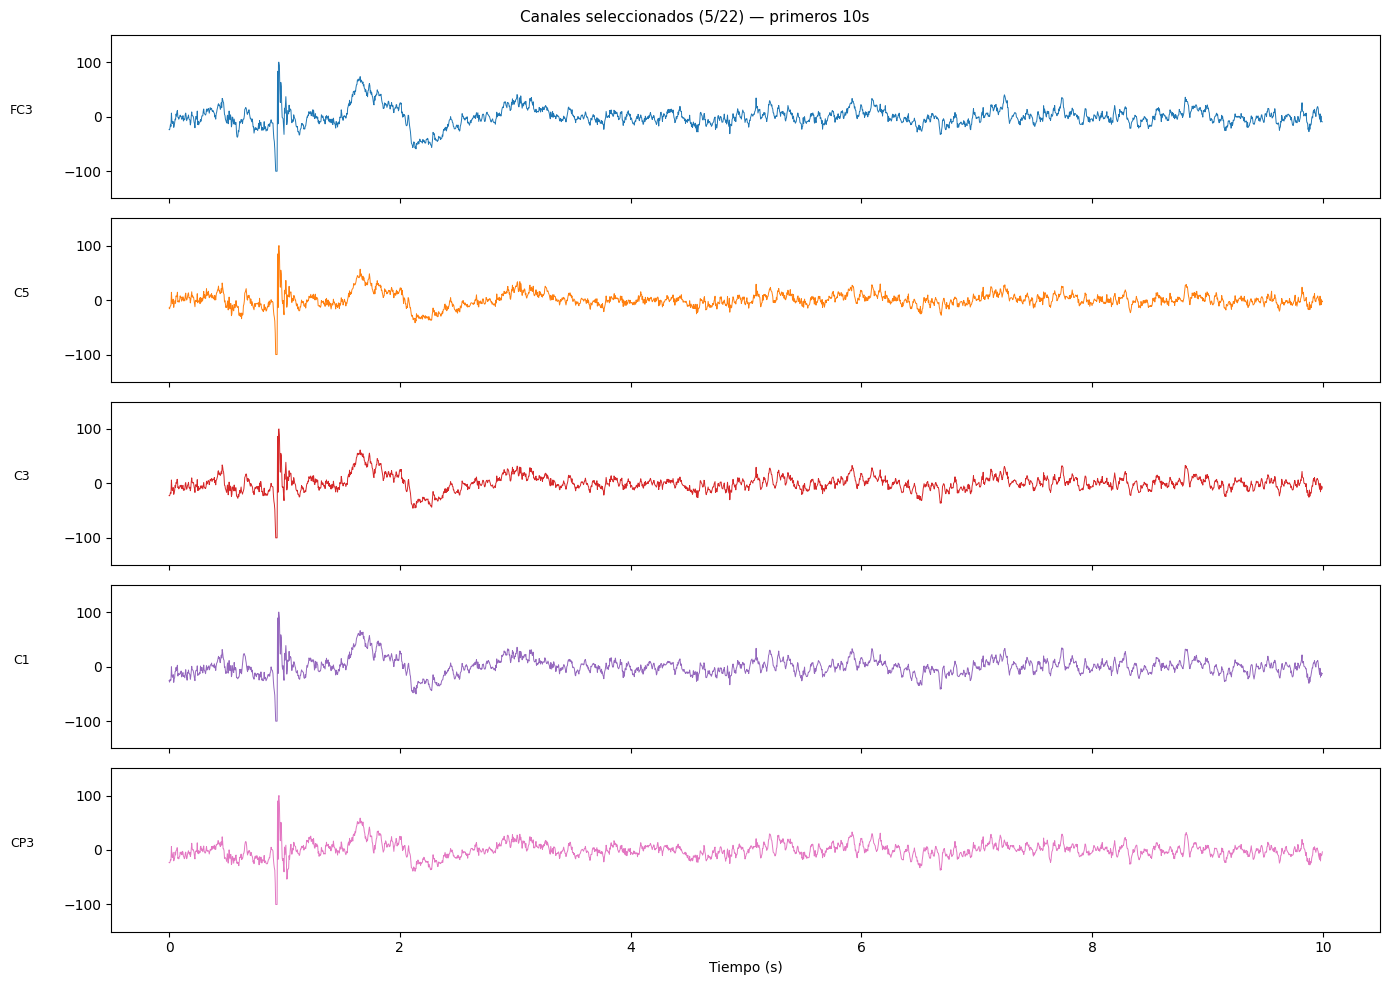

In [53]:

channel_name_map = {
    nombre: real
    for nombre, real in zip(CHANNEL_LIST, train_raw.ch_names[:22])
}
print("Mapa nombre → nombre real en archivo:")
for k, v in channel_name_map.items():
    print(f"  {k:6s} → {v}")

# Validar que existan los canales pedidos
selected_real = []
for ch in SEL_CHANNELS:
    if ch not in channel_name_map:
        raise ValueError(f"Canal '{ch}' no existe. Válidos: {list(channel_name_map.keys())}")
    selected_real.append(channel_name_map[ch])

print(f"\n✅ Canales seleccionados: {SEL_CHANNELS}")
print(f"   Nombres reales:        {selected_real}")

# Extraer solo esos canales
train_raw_sel = train_raw.copy().pick_channels(selected_real)
test_raw_sel  = test_raw.copy().pick_channels(selected_real)
train_data_raw = train_raw_sel.get_data()   # (n_ch, n_samples)
test_data_raw  = test_raw_sel.get_data()
N_CH = len(selected_real)

# Visualización
fig, axes = plt.subplots(N_CH, 1, figsize=(14, 2*N_CH), sharex=True)
t = np.arange(train_data_raw.shape[1]) / FS
colors = plt.cm.tab10(np.linspace(0, 0.6, N_CH))
for i, (ax, ch) in enumerate(zip(axes, SEL_CHANNELS)):
    ax.plot(t[:FS*10], train_data_raw[i, :FS*10]*1e6, lw=0.7, color=colors[i])
    ax.set_ylabel(ch, fontsize=9, rotation=0, labelpad=30)
    ax.set_ylim(-150, 150)
axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle(f'Canales seleccionados ({N_CH}/{len(CHANNEL_LIST)}) — primeros 10s', fontsize=11)
plt.tight_layout()
plt.show()

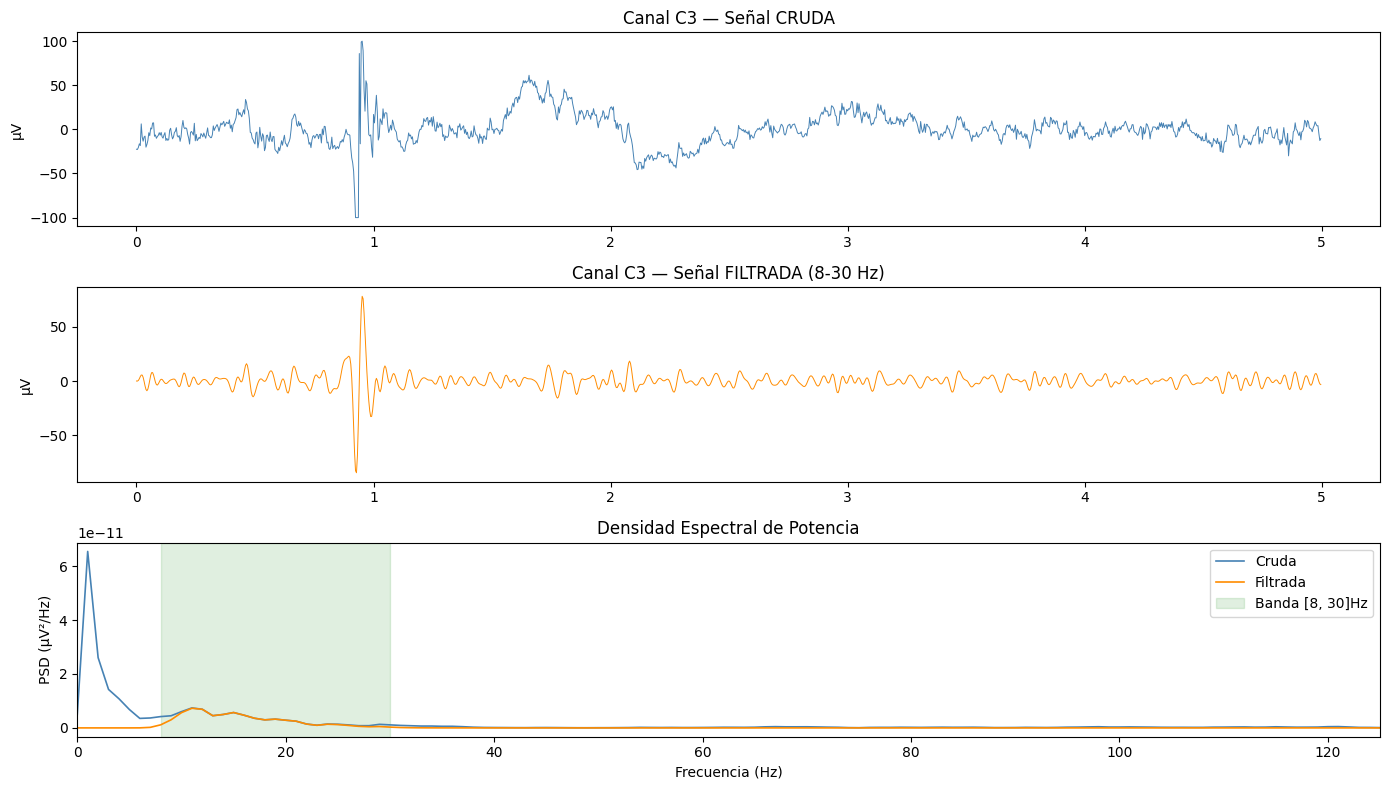

In [66]:
# Filtrado bandpass
b, a = get_bandpass_coef(N=4, low=BAND_PASS[0], high=BAND_PASS[1], fs=FS)

# Aplicar filtro (zero-phase con filtfilt)
train_data_filt = signal.filtfilt(b, a, train_data_raw, axis=1)
test_data_filt  = signal.filtfilt(b, a, test_data_raw,  axis=1)

# Visualización: antes vs después en canal C3 
ch_idx = SEL_CHANNELS.index('C3') if 'C3' in SEL_CHANNELS else 0
n_show = FS * 5   # 5 segundos
t5 = np.arange(n_show) / FS

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(t5, train_data_raw[ch_idx, :n_show]*1e6,  lw=0.7, color='steelblue')
axes[0].set_title(f'Canal {SEL_CHANNELS[ch_idx]} — Señal CRUDA')
axes[0].set_ylabel('µV')

axes[1].plot(t5, train_data_filt[ch_idx, :n_show]*1e6, lw=0.7, color='darkorange')
axes[1].set_title(f'Canal {SEL_CHANNELS[ch_idx]} — Señal FILTRADA ({BAND_PASS[0]}-{BAND_PASS[1]} Hz)')
axes[1].set_ylabel('µV')

# PSD antes vs después
from scipy.signal import welch
f_raw,  p_raw  = welch(train_data_raw[ch_idx, :2000],  fs=FS, nperseg=FS, noverlap=125)
f_filt, p_filt = welch(train_data_filt[ch_idx, :2000], fs=FS, nperseg=FS, noverlap=125)
axes[2].plot(f_raw,  p_raw,  lw=1.2, color='steelblue',   label='Cruda')
axes[2].plot(f_filt, p_filt, lw=1.2, color='darkorange',  label='Filtrada')
axes[2].axvspan(BAND_PASS[0], BAND_PASS[1], alpha=0.12, color='green', label=f'Banda {BAND_PASS}Hz')
axes[2].set_xlim(0, FS/2); axes[2].set_xlabel('Frecuencia (Hz)')
axes[2].set_ylabel('PSD (µV²/Hz)'); axes[2].legend(); axes[2].set_title('Densidad Espectral de Potencia')

plt.tight_layout(); plt.show()

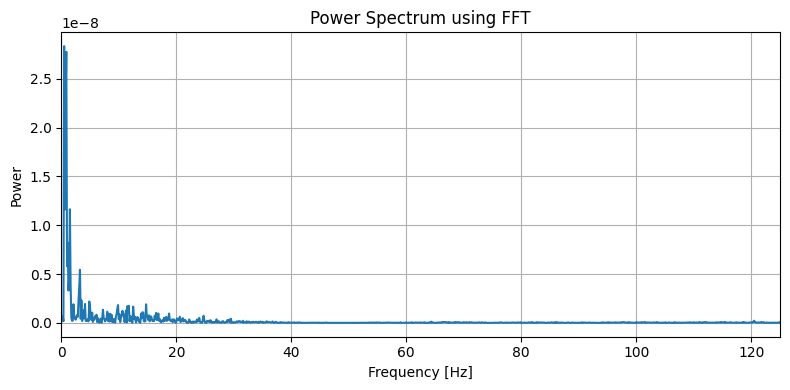

In [62]:
n_samples = train_data_raw[ch_idx, :2000].shape[0]

# FFT
fft_values = np.fft.rfft(train_data_raw[ch_idx, :2000])
frequencies = np.fft.rfftfreq(n_samples, d=1/fs)

# Power spectrum
power = np.abs(fft_values) ** 2 / n_samples

# Plot
plt.figure(figsize=(8, 4))
plt.plot(frequencies, power)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.title("Power Spectrum using FFT")
plt.xlim(0, fs / 2)
plt.grid(True)
plt.tight_layout()
plt.show()

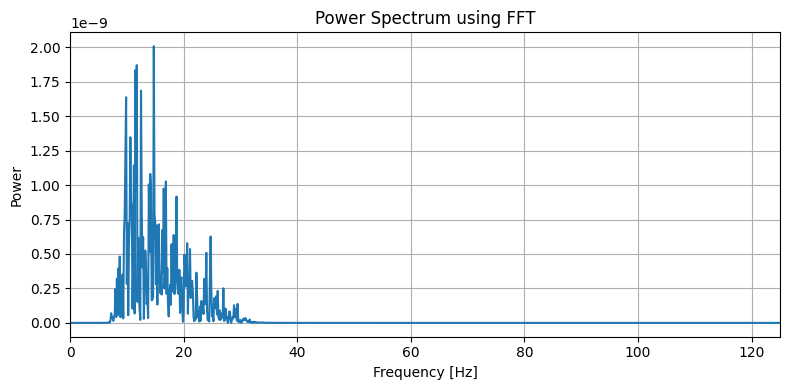

In [63]:
n_samples = train_data_filt[ch_idx, :2000].shape[0]

# FFT
fft_values = np.fft.rfft(train_data_filt[ch_idx, :2000])
frequencies = np.fft.rfftfreq(n_samples, d=1/fs)

# Power spectrum
power = np.abs(fft_values) ** 2 / n_samples

# Plot
plt.figure(figsize=(8, 4))
plt.plot(frequencies, power)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.title("Power Spectrum using FFT")
plt.xlim(0, fs / 2)
plt.grid(True)
plt.tight_layout()
plt.show()

 - no lo hago semi-log --> no-log 
 - verificar por que no sale el espectro de la señal cruda, ver en la documentación y en el codigo o manipulacion del archivo.
 - usar TF --> 
 - Anotar caracteristicas del dataset, protocolo que se uso para ver si se puede extraer una tarea que es reposo o descanso (permite visualizar la diferencia entre moviemiento y descanso), tiempos y datos para corroborar estados y cambios de estados.
 - ver axes y plt.


✅ Extracción completada.
Dataset: 288 trials encontrados.
Clases detectadas (0=Izq, 1=Der, 2=Pies, 3=Lengua): (array([0., 1., 2., 3.]), array([72, 72, 72, 72]))


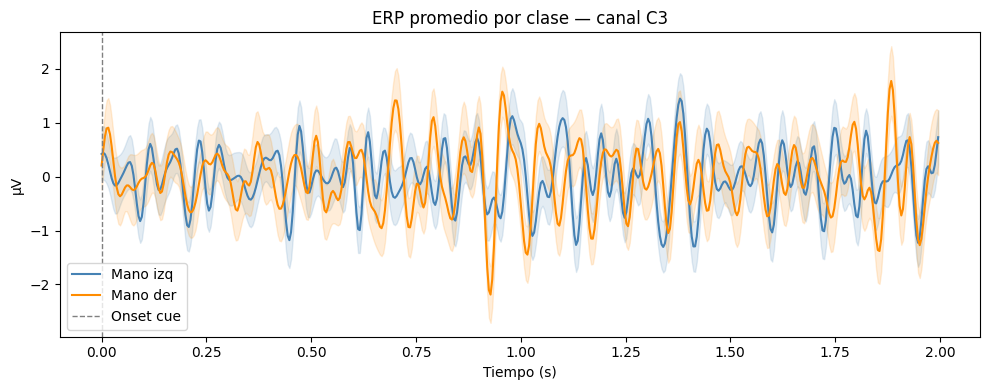

In [55]:
# Definimos los códigos que representan las clases reales (769 a 772)
# Basado en tu salida: {'769': 7, '770': 8, '771': 9, '772': 10}
class_codes = ['769', '770', '771', '772']

# Obtenemos los IDs internos de MNE para esas clases
# Esto reemplaza a train_index_codes
train_index_codes = [events_id[c] for c in class_codes if c in events_id]

# Filtramos el array 'events' para conservar solo los disparadores de clase
# 'events' tiene formato [sample_index, 0, event_id]
mask_clases = np.isin(events[:, -1], train_index_codes)
train_events = events[mask_clases]

# Inicializamos los tensores usando la cantidad de eventos encontrados
n_train_trials = len(train_events)
X_train = np.zeros((seg_samples, N_CH, n_train_trials))
y_train = np.zeros(n_train_trials)

# Llenamos el tensor X_train e y_train
# Invertimos el diccionario para buscar el código (ej. '769') a partir del ID (ej. 7)
id_to_code = {v: k for k, v in events_id.items()}

for i, e in enumerate(train_events):
    start = int(e[0] + offset_samples)
    end   = start + seg_samples
    
    # Extraer segmento y trasponer a (muestras, canales)
    X_train[:, :, i] = train_data_filt[:, start:end].T
    
    # Extraer la clase: restamos 769 para que las etiquetas sean 0, 1, 2, 3
    code_str = id_to_code[e[-1]]
    y_train[i] = int(code_str) - 769

print(f"✅ Extracción completada.")
print(f"Dataset: {n_train_trials} trials encontrados.")
print(f"Clases detectadas (0=Izq, 1=Der, 2=Pies, 3=Lengua): {np.unique(y_train, return_counts=True)}")

# Visualización: promedio de épocas por clase
ch_idx = 2   # C3
t_ep   = np.arange(seg_samples) / FS
fig, ax = plt.subplots(figsize=(10, 4))
for cls in CLASS_LABELS:
    mask  = (y_train == cls)
    mean  = X_train[:, ch_idx, mask].mean(axis=1) * 1e6
    sem   = X_train[:, ch_idx, mask].std(axis=1)  * 1e6 / np.sqrt(mask.sum())
    label = {1:'Mano izq', 2:'Mano der', 3:'Pies', 4:'Lengua'}.get(cls, str(cls))
    color = ['steelblue','darkorange','green','red'][cls-1]
    ax.plot(t_ep, mean, lw=1.5, label=label, color=color)
    ax.fill_between(t_ep, mean-sem, mean+sem, alpha=0.15, color=color)

ax.axvline(0, color='gray', lw=1, ls='--', label='Onset cue')
ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('µV')
ax.set_title(f'ERP promedio por clase — canal {SEL_CHANNELS[ch_idx]}')
ax.legend(); plt.tight_layout(); plt.show()

In [56]:
# Loop completo sobre todos los sujetos
def read_BCI_IV_DS2a(filename, class_labels=CLASS_LABELS, band_pass=BAND_PASS,
                     segment_length=SEGMENT_LENGTH, offset=OFFSET,
                     selected_channels=SEL_CHANNELS):

    n_subjects = 9
    stim_codes_sel = [STIM_CODES[i-1] for i in class_labels]
    seg_samples    = segment_length * FS
    offset_samples = int(offset * FS)
    subject_data   = {}

    for subj in range(n_subjects):
        train_raw = read_raw_gdf(train_eeg_files[subj], preload=True, verbose=False)
        test_raw  = read_raw_gdf(test_eeg_files[subj],  preload=True, verbose=False)

        # --- canales
        ch_map  = {n: r for n, r in zip(CHANNEL_LIST, train_raw.ch_names[:22])}
        sel_r   = [ch_map[c] for c in selected_channels]
        train_raw.pick_channels(sel_r); test_raw.pick_channels(sel_r)
        n_ch    = len(sel_r)
        tr_data = train_raw.get_data()
        te_data = test_raw.get_data()

        # --- filtro
        if band_pass:
            b, a = get_bandpass_coef(N=4, low=band_pass[0], high=band_pass[1], fs=FS)
            tr_data = signal.filtfilt(b, a, tr_data, axis=1)
            te_data = signal.filtfilt(b, a, te_data, axis=1)

        # --- segmentación train
        events, events_id = events_from_annotations(train_raw)
        tr_idx_codes = [events_id[str(s)] for s in stim_codes_sel]
        tr_labels    = sio.loadmat(train_label_files[subj], squeeze_me=True)['classlabel']
        tr_labels    = np.array([i for i in tr_labels if i in class_labels])
        n_tr         = np.sum(np.isin(events[:, -1], tr_idx_codes))
        X_tr = np.zeros((seg_samples, n_ch, n_tr))
        y_tr = np.zeros(n_tr)
        kl, vl = list(events_id.keys()), list(events_id.values())
        i = 0
        for e in events:
            if e[-1] in tr_idx_codes:
                code = int(kl[vl.index(e[-1])])
                s    = int(e[0] + offset_samples)
                X_tr[:, :, i] = tr_data[:, s:s+seg_samples].T
                y_tr[i]       = int(code - 768); i += 1
        assert np.all(y_tr == tr_labels)

        # --- segmentación test
        events, events_id = events_from_annotations(test_raw)
        te_labels = sio.loadmat(test_label_files[subj], squeeze_me=True)['classlabel']
        te_mask   = np.isin(te_labels, class_labels)
        n_te      = te_labels.size
        X_te      = np.zeros((seg_samples, n_ch, n_te))
        i = 0
        for e in events:
            if e[-1] == events_id['783']:
                s = int(e[0] + offset_samples)
                X_te[:, :, i] = te_data[:, s:s+seg_samples].T; i += 1
        X_te = X_te[:, :, te_mask]
        y_te = te_labels[te_mask]

        subject_data[f'subject_{subj+1}'] = dict(X_train=X_tr, y_train=y_tr,
                                                  X_test=X_te,  y_test=y_te)
        print(f"  Sujeto {subj+1}: X_train{X_tr.shape}  X_test{X_te.shape}")

    return subject_data

data = read_BCI_IV_DS2a(FILENAME)

# ── Guardar
out_path = './notebooks/BCI_IV_2a_clases_8_30.npy'
np.save(out_path, data)
print(f"\n✅ Dataset guardado en: {out_path}")

# Visualización resumen: tamaños por sujeto
subjs = list(data.keys())
n_train = [data[s]['X_train'].shape[2] for s in subjs]
n_test  = [data[s]['X_test'].shape[2]  for s in subjs]
x = np.arange(len(subjs))
ax.bar(x-0.2, n_train, 0.4, label='Train trials', color='steelblue')
ax.bar(x+0.2, n_test,  0.4, label='Test trials',  color='darkorange')
ax.set_xticks(x); ax.set_xticklabels([s.replace('subject_','S') for s in subjs])
ax.set_ylabel('Número de trials'); ax.set_title('Trials por sujeto')
ax.legend(); plt.tight_layout(); plt.show()

C:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


IndexError: list index out of range